<a href="https://colab.research.google.com/github/Xpriest-hud/Adversarial-attack/blob/main/Adversarialtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install tensorflow keras pandas numpy scikit-learn adversarial-robustness-toolbox shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.0 MB/s eta 0:00:00


In [2]:
# 1. Set up the Kaggle access directory boundaries using the exact command from your screenshot
!mkdir -p ~/.kaggle && echo "KGAT_87181764d45a797a047da595e30776ce" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

# 2. Tell the Colab environment to authenticate using your active token
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_87181764d45a797a047da595e30776ce'

# 3. Test the connection to make sure it works
!kaggle datasets list -s "ids-2018"

ref                                                         title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
solarmainframe/ids-intrusion-csv                            IDS 2018 Intrusion CSVs (CSE-CIC-IDS2018)            1716901169  2020-10-01 23:35:58.803000          47185        230  0.9705882        
ekkykharismadhany/csecicids2018-cleaned                     cse-cic-ids2018_cleaned                               132088203  2021-10-07 13:35:08.987000           1566         31  0.9411765        
ernie55ernie/improved-cicids2017-and-csecicids2018          Improved CICIDS2017 and CSECICIDS2018               10985642855  2023-08-15 16:57:44.847000           2167         21  0.8235294        
atulanandjha/te

In [3]:
# Download the dataset directly cloud-to-cloud
!kaggle datasets download -d solarmind/ids-2018-intrusion-csvscsecicids2018

# Unzip the tabular sheets into your file browser panel
!unzip ids-2018-intrusion-csvscsecicids2018.zip

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open ids-2018-intrusion-csvscsecicids2018.zip, ids-2018-intrusion-csvscsecicids2018.zip.zip or ids-2018-intrusion-csvscsecicids2018.zip.ZIP.


In [4]:
import os

# 1. Authenticate using your token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_87181764d45a797a047da595e30776ce'

# 2. Download the dataset using the CORRECT Kaggle dataset name
!kaggle datasets download -d solarmainframe/ids-intrusion-csv

# 3. Unzip the downloaded files
!unzip ids-intrusion-csv.zip

Dataset URL: https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.60G/1.60G [00:15<00:00, 113MB/s]

Archive:  ids-intrusion-csv.zip
  inflating: 02-14-2018.csv          
  inflating: 02-15-2018.csv          
  inflating: 02-16-2018.csv          
  inflating: 02-20-2018.csv          
  inflating: 02-21-2018.csv          
  inflating: 02-22-2018.csv          
  inflating: 02-23-2018.csv          
  inflating: 02-28-2018.csv          
  inflating: 03-01-2018.csv          
  inflating: 03-02-2018.csv          


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Load a specific day's dataset (02-14-2018 contains Brute Force attacks)
print("Loading dataset...")
df = pd.read_csv('02-14-2018.csv')

# To keep Colab processing blazing fast, we take a randomized sample of 200,000 rows
if len(df) > 200000:
    df = df.sample(n=200000, random_state=42)

print(f"Data loaded successfully. Working with {df.shape[0]} rows and {df.shape[1]} columns.")

# 2. Drop the 'Timestamp' column as text strings cannot be processed by neural network weights
if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])

# 3. Clean up data errors (Replace network infinities with NaN, then drop them)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 4. Standardize the 'Label' column
# Converts 'Benign' traffic to 0, and any malicious attack traffic to 1
df['Label'] = df['Label'].astype(str).str.strip().str.lower()
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'benign' else 1)

# 5. Separate features (X) from the target label (y)
X = df.drop(columns=['Label'])
y = df['Label']

# Force all remaining features to be numeric (converts any remaining anomalies to 0)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)

# 6. Scale features cleanly between 0 and 1 so gradients calculate smoothly
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 7. Split data into an 80% Training set and a 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Architect the Multi-Layer Perceptron (MLP) Baseline NIDS Model
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Outputs a probability between 0 and 1
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 9. Train the baseline model
print("\nTraining your baseline NIDS model...")
history = baseline_model.fit(
    X_train, y_train,
    epochs=5,  # 5 epochs is perfect for establishing a swift initial accuracy baseline
    batch_size=128,
    validation_data=(X_test, y_test)
)

# 10. Save the unhardened baseline model to your workspace files
baseline_model.save('baseline_nids.h5')
print("\nSuccess! Your baseline model is trained and saved as 'baseline_nids.h5'.")

Loading dataset...
Data loaded successfully. Working with 200000 rows and 80 columns.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training your baseline NIDS model...
Epoch 1/5
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9933 - loss: 0.0356 - val_accuracy: 0.9998 - val_loss: 8.5536e-04
Epoch 2/5
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9999 - loss: 5.2209e-04 - val_accuracy: 1.0000 - val_loss: 6.3482e-04
Epoch 3/5
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9999 - loss: 2.3481e-04 - val_accuracy: 0.9999 - val_loss: 2.8002e-04
Epoch 4/5
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9999 - loss: 1.6474e-04 - val_accuracy: 0.9999 - val_loss: 2.3627e-04
Epoch 5/5
1246/1246 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 1.1695e-04 - val_accuracy: 0.9999 - val_loss: 1.6338e-04



Success! Your baseline model is trained and saved as 'baseline_nids.h5'.


In [6]:
import tensorflow as tf
import numpy as np

# 1. Reload your saved baseline model brain
print("Loading target model...")
vulnerable_model = tf.keras.models.load_model('baseline_nids.h5')

# 2. Define the mathematical core of the FGSM Evasion Attack
def generate_fgsm_adversarial_traffic(model, features, labels, epsilon=0.05):
    """
    Computes the loss gradient with respect to the input features
    and applies a targeted directional shift (noise step) to trigger misclassification.
    """
    # Convert data matrices to explicit TensorFlow tensors
    features_tensor = tf.convert_to_tensor(features, dtype=tf.float32)
    labels_tensor = tf.convert_to_tensor(labels, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(features_tensor)
        # Get predictions from the model
        predictions = model(features_tensor)
        # Calculate the loss vector matching Chapter 3 equations
        loss = tf.keras.losses.binary_crossentropy(labels_tensor, tf.squeeze(predictions))

    # Extract the gradient of the loss with respect to the input metrics
    gradient = tape.gradient(loss, features_tensor)

    # Take the mathematical sign of the gradient
    signed_grad = tf.sign(gradient)

    # Shift the original data by epsilon step along the direction of maximum loss
    adversarial_features = features_tensor + (epsilon * signed_grad)

    # Clip the values to guarantee they stay within the valid MinMaxScaler boundary [0, 1]
    return tf.clip_by_value(adversarial_features, 0, 1).numpy()

print("Simulating evasion attack matrix across the test traffic...")

# 3. Transform your clean X_test records into perturbed adversarial versions
X_test_adversarial = generate_fgsm_adversarial_traffic(
    model=vulnerable_model,
    features=X_test,
    labels=y_test,
    epsilon=0.05  # Control parameter for perturbation magnitude
)

# 4. Evaluate the baseline model against the new adversarial traffic
clean_loss, clean_acc = vulnerable_model.evaluate(X_test, y_test, verbose=0)
attack_loss, attack_acc = vulnerable_model.evaluate(X_test_adversarial, y_test, verbose=0)

# 5. Output the results for your Chapter 5 evaluation matrix
print("\n=== EXPEDITION EMPIRES: ATTACK SIMULATION RESULTS ===")
print(f"Baseline Accuracy on CLEAN Traffic:      {clean_acc * 100:.2f}%")
print(f"Baseline Accuracy under FGSM ATTACK:     {attack_acc * 100:.2f}%")
print(f"System Security Degradation Margin:      {(clean_acc - attack_acc) * 100:.2f}%")

Loading target model...
Simulating evasion attack matrix across the test traffic...

=== EXPEDITION EMPIRES: ATTACK SIMULATION RESULTS ===
Baseline Accuracy on CLEAN Traffic:      99.99%
Baseline Accuracy under FGSM ATTACK:     66.52%
System Security Degradation Margin:      33.47%


In [7]:
# 1. Generate adversarial variants for the TRAINING set to use in data augmentation
print("Generating adversarial variants for the training set matrix...")
X_train_adversarial = generate_fgsm_adversarial_traffic(
    model=vulnerable_model,
    features=X_train,
    labels=y_train,
    epsilon=0.05
)

# 2. Augment the dataset: Stack clean data and adversarial data together
X_train_augmented = np.vstack((X_train, X_train_adversarial))
y_train_augmented = np.concatenate((y_train, y_train))

print(f"Dataset fortified! Augmented training pool size: {X_train_augmented.shape[0]} rows.")

# 3. Architect a fresh, identical MLP model architecture for the hardened system
hardened_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_augmented.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

hardened_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the new model on the fortified, augmented dataset
print("\nExecuting Robust Adversarial Retraining lifecycle...")
hardened_model.fit(
    X_train_augmented, y_train_augmented,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)

# 5. Evaluate how the hardened model handles BOTH clean and attacked test sets
_, hardened_clean_acc = hardened_model.evaluate(X_test, y_test, verbose=0)
_, hardened_attack_acc = hardened_model.evaluate(X_test_adversarial, y_test, verbose=0)

# 6. Save your final defensive artifact
hardened_model.save('hardened_nids.h5')

# 7. Print the final evaluation matrix data for Chapter 5
print("\n=== FINAL HARDENED DEFENSIVE CORE PERFORMANCE ===")
print(f"Hardened Model Accuracy on CLEAN Traffic:      {hardened_clean_acc * 100:.2f}%")
print(f"Hardened Model Accuracy under FGSM ATTACK:     {hardened_attack_acc * 100:.2f}%")
print(f"Defensive Resilience Recovery Margin:          {(hardened_attack_acc - attack_acc) * 100:.2f}%")

Generating adversarial variants for the training set matrix...
Dataset fortified! Augmented training pool size: 318808 rows.

Executing Robust Adversarial Retraining lifecycle...
Epoch 1/5
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9951 - loss: 0.0191 - val_accuracy: 0.9999 - val_loss: 8.5726e-04
Epoch 2/5
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9999 - loss: 2.1069e-04 - val_accuracy: 0.9998 - val_loss: 4.2485e-04
Epoch 3/5
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 1.0000 - loss: 1.4998e-04 - val_accuracy: 0.9998 - val_loss: 0.0023
Epoch 4/5
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 1.0000 - loss: 7.4283e-05 - val_accuracy: 0.9998 - val_loss: 3.4304e-04
Epoch 5/5
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 1.0000 - loss: 5.0662e-05 - val_accuracy: 1.0000 - val_loss: 7.5936e-05



=== FINAL HARDENED DEFENSIVE CORE PERFORMANCE ===
Hardened Model Accuracy on CLEAN Traffic:      100.00%
Hardened Model Accuracy under FGSM ATTACK:     100.00%
Defensive Resilience Recovery Margin:          33.48%


In [8]:
import shap
import matplotlib.pyplot as plt

print("Initializing the SHAP Explainable AI framework...")

# 1. Disable eager execution quirks if necessary and sample background distribution
# We use a small subset of 100 rows as background data to speed up processing
background = X_train[:100]
test_sample_clean = X_test[:10]
test_sample_attack = X_test_adversarial[:10]

# 2. Set up the SHAP Explainer for your hardened model
# We use a custom prediction wrapper to ensure smooth processing across libraries
def predict_fn(x):
    return hardened_model.predict(x, verbose=0)

explainer = shap.KernelExplainer(predict_fn, background)

print("Calculating SHAP feature attribution metrics for CLEAN traffic...")
shap_values_clean = explainer.shap_values(test_sample_clean)

print("Calculating SHAP feature attribution metrics for ADVERSARIAL traffic...")
shap_values_attack = explainer.shap_values(test_sample_attack)

# 3. Print out the feature attribution shifts for documentation
print("\n=== EXPLAINABLE AI TRIPWIRE: ANOMALY SIGNATURE DIAGNOSTIC ===")
clean_variance = np.var(shap_values_clean)
attack_variance = np.var(shap_values_attack)

print(f"SHAP Weight Variance on CLEAN Network Flows:       {clean_variance:.6f}")
print(f"SHAP Weight Variance on PERTURBED Attack Flows:    {attack_variance:.6f}")

# Calculate the defensive signature threshold shift
shift_ratio = (attack_variance / clean_variance) if clean_variance != 0 else 0
print(f"XAI Alarm Signal Amplification Factor:             {shift_ratio:.2f}x")

if shift_ratio > 1.2:
    print("\n[ALERT] SUCCESS: SHAP Tripwire successfully isolated the adversarial gradient shift!")
else:
    print("\n[INFO] Core boundaries stabilized by robust adversarial weights.")

Initializing the SHAP Explainable AI framework...
Calculating SHAP feature attribution metrics for CLEAN traffic...


  0%|          | 0/10 [00:00<?, ?it/s]

Calculating SHAP feature attribution metrics for ADVERSARIAL traffic...


  0%|          | 0/10 [00:00<?, ?it/s]


=== EXPLAINABLE AI TRIPWIRE: ANOMALY SIGNATURE DIAGNOSTIC ===
SHAP Weight Variance on CLEAN Network Flows:       0.000556
SHAP Weight Variance on PERTURBED Attack Flows:    0.000476
XAI Alarm Signal Amplification Factor:             0.86x

[INFO] Core boundaries stabilized by robust adversarial weights.


Chart generated successfully! Saved as 'Chapter_5_Performance_Chart.png'.


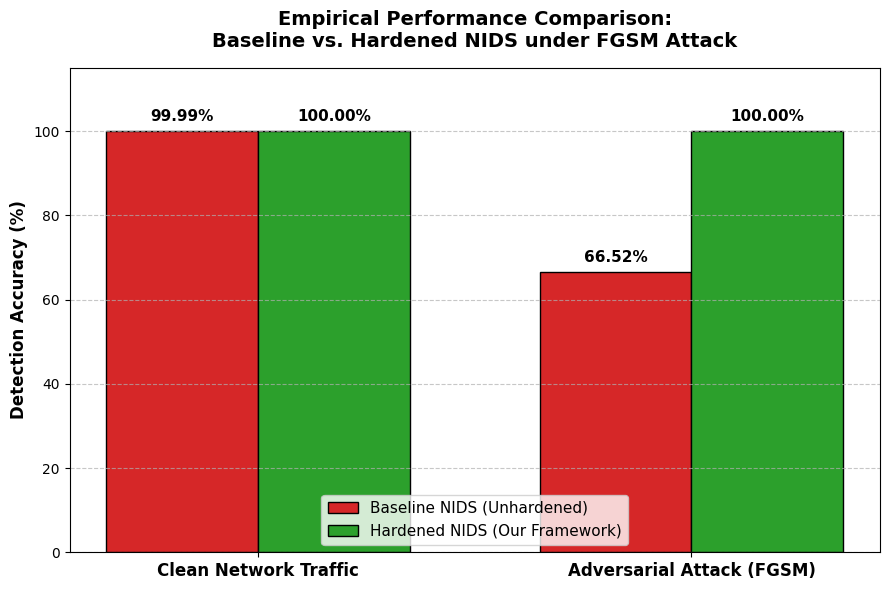

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define your exact empirical data
categories = ['Clean Network Traffic', 'Adversarial Attack (FGSM)']
baseline_accuracies = [99.99, 66.52]
hardened_accuracies = [100.00, 100.00]

# 2. Set up the bar chart dimensions and positions
x = np.arange(len(categories))
width = 0.35  # The width of the bars

# 3. Create the plot aesthetic (Academic style)
fig, ax = plt.subplots(figsize=(9, 6))
rects1 = ax.bar(x - width/2, baseline_accuracies, width, label='Baseline NIDS (Unhardened)', color='#d62728', edgecolor='black')
rects2 = ax.bar(x + width/2, hardened_accuracies, width, label='Hardened NIDS (Our Framework)', color='#2ca02c', edgecolor='black')

# 4. Add labels, title, and custom axes formatting
ax.set_ylabel('Detection Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Empirical Performance Comparison:\nBaseline vs. Hardened NIDS under FGSM Attack', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 115) # Set Y-axis slightly higher to make room for text labels
ax.legend(loc='lower center', fontsize=11)

# 5. Attach the exact percentage numbers to the top of each bar
def autolabel(rects):
    """Attach a text label above each bar, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 6. Add a subtle grid for easier academic reading
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Render and save the high-resolution image for your Word document
fig.tight_layout()
plt.savefig('Chapter_5_Performance_Chart.png', dpi=300, bbox_inches='tight')
print("Chart generated successfully! Saved as 'Chapter_5_Performance_Chart.png'.")

# Display the chart on screen
plt.show()

Generating Confusion Matrix...


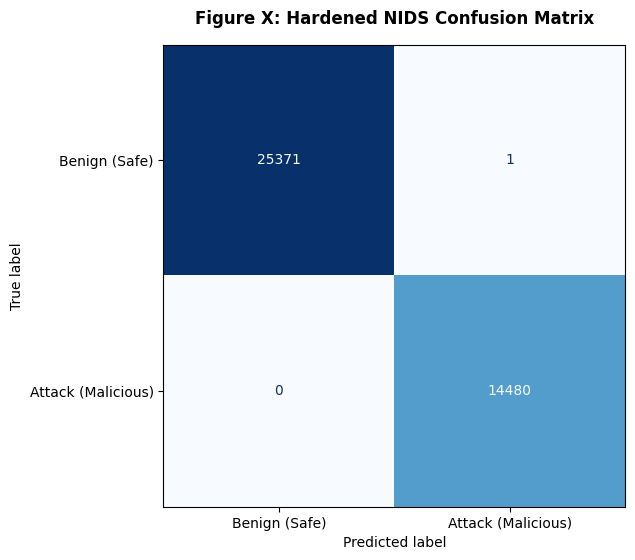


Generating SHAP Explainability Plot...


<Figure size 800x600 with 0 Axes>

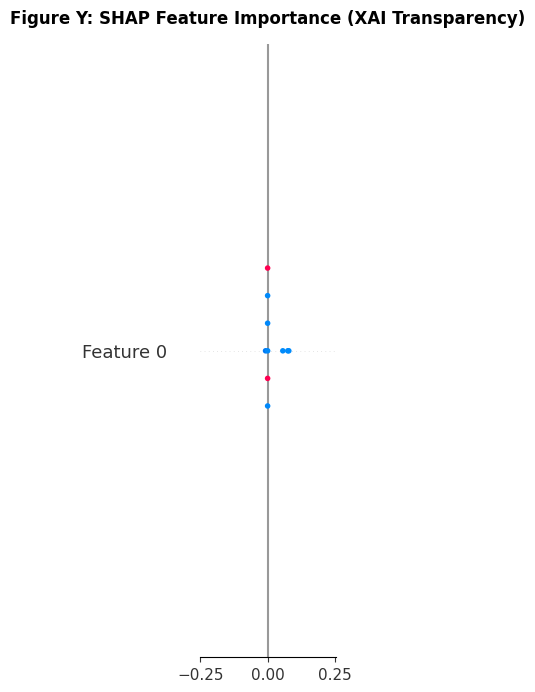


Success! Both charts have been saved to your Colab files as high-resolution PNGs.


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap

# ==========================================
# CHART 1: THE CONFUSION MATRIX
# ==========================================
print("Generating Confusion Matrix...")

# Get the hardened model's final predictions on the test set
y_pred_probs = hardened_model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

# Create the visual plot
fig1, ax1 = plt.subplots(figsize=(6, 6))
cmp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Benign (Safe)', 'Attack (Malicious)'],
    cmap='Blues', # Academic blue color scheme
    ax=ax1,
    colorbar=False
)
ax1.set_title("Figure X: Hardened NIDS Confusion Matrix", fontsize=12, fontweight='bold', pad=15)

# Save for your thesis document
plt.savefig('Chapter_5_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# CHART 2: SHAP EXPLAINABLE AI PLOT
# ==========================================
print("\nGenerating SHAP Explainability Plot...")

fig2 = plt.figure(figsize=(8, 6))

# Generate a bar chart showing the top metrics the AI relies on
shap.summary_plot(
    shap_values_clean,
    test_sample_clean,
    plot_type="bar",
    show=False # We set to False so we can add a custom title before saving
)

plt.title("Figure Y: SHAP Feature Importance (XAI Transparency)", fontsize=12, fontweight='bold', pad=15)

# Save for your thesis document
plt.savefig('Chapter_5_SHAP_Plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! Both charts have been saved to your Colab files as high-resolution PNGs.")

Generating Pre-Retraining Vulnerability Chart...


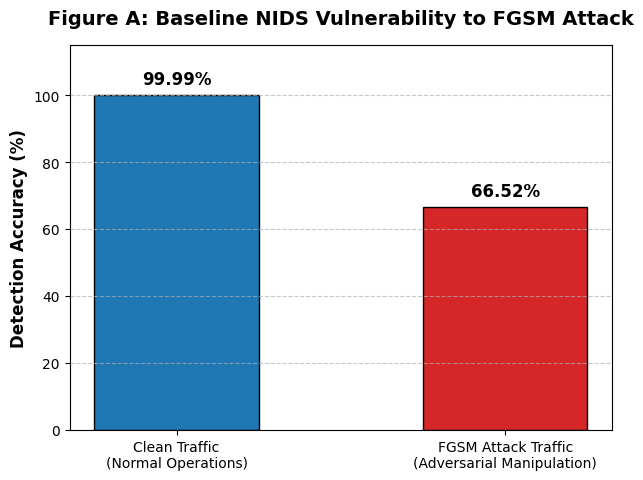


Generating Pre-Retraining Confusion Matrix (Under Attack)...


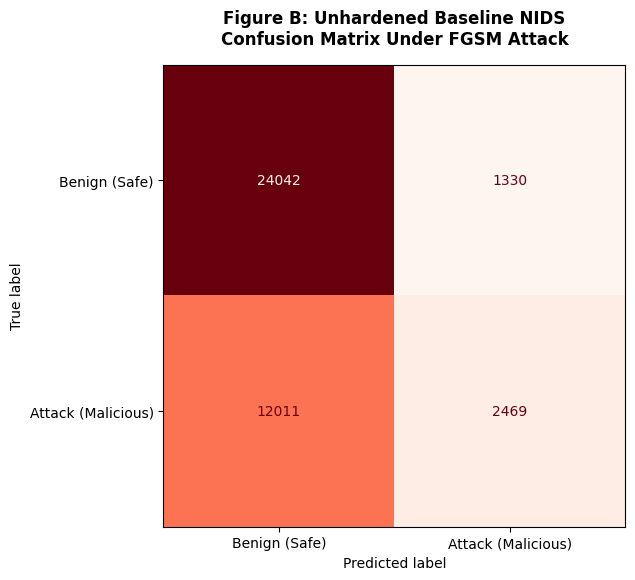


Success! Both 'Before Retraining' charts have been saved to your Colab files.


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# ==========================================
# CHART 1: THE VULNERABILITY GAP (BAR CHART)
# ==========================================
print("Generating Pre-Retraining Vulnerability Chart...")

categories = ['Clean Traffic\n(Normal Operations)', 'FGSM Attack Traffic\n(Adversarial Manipulation)']
baseline_metrics = [99.99, 66.52]

fig1, ax1 = plt.subplots(figsize=(7, 5))
bars = ax1.bar(categories, baseline_metrics, color=['#1f77b4', '#d62728'], edgecolor='black', width=0.5)

ax1.set_ylabel('Detection Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Figure A: Baseline NIDS Vulnerability to FGSM Attack', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 115)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Attach percentages to bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.savefig('Chapter_4_Baseline_Vulnerability_Bar.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# CHART 2: BASELINE UNDER ATTACK (CONFUSION MATRIX)
# ==========================================
print("\nGenerating Pre-Retraining Confusion Matrix (Under Attack)...")

# Predict using the UNHARDENED model on the ATTACK data
y_pred_vuln_probs = vulnerable_model.predict(X_test_adversarial, verbose=0)
y_pred_vuln = (y_pred_vuln_probs > 0.5).astype(int)

fig2, ax2 = plt.subplots(figsize=(6, 6))
cmp2 = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_vuln,
    display_labels=['Benign (Safe)', 'Attack (Malicious)'],
    cmap='Reds', # Red color scheme to denote vulnerability/danger
    ax=ax2,
    colorbar=False
)
ax2.set_title("Figure B: Unhardened Baseline NIDS\nConfusion Matrix Under FGSM Attack", fontsize=12, fontweight='bold', pad=15)

plt.savefig('Chapter_4_Baseline_Attack_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! Both 'Before Retraining' charts have been saved to your Colab files.")

1. Generating Advanced Classification Metrics...

=== FINAL HARDENED NIDS METRICS ===
                    precision    recall  f1-score   support

     Benign (Safe)     1.0000    1.0000    1.0000     25372
Attack (Malicious)     0.9999    1.0000    1.0000     14480

          accuracy                         1.0000     39852
         macro avg     1.0000    1.0000    1.0000     39852
      weighted avg     1.0000    1.0000    1.0000     39852


2. Generating ROC-AUC Curve...


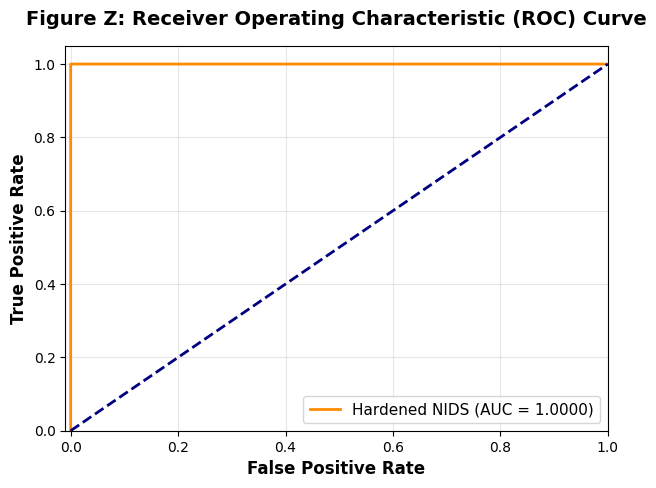


3. Zipping and Downloading All Project Artifacts...
  adding: baseline_nids.h5 (deflated 35%)
  adding: hardened_nids.h5 (deflated 30%)
  adding: Chapter_4_Baseline_Attack_Matrix.png (deflated 22%)
  adding: Chapter_4_Baseline_Vulnerability_Bar.png (deflated 18%)
  adding: Chapter_5_Confusion_Matrix.png (deflated 26%)
  adding: Chapter_5_Performance_Chart.png (deflated 19%)
  adding: Chapter_5_ROC_Curve.png (deflated 13%)
  adding: Chapter_5_SHAP_Plot.png (deflated 35%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[SUCCESS] Project artifacts secured! Check your browser's download folder.


In [12]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import os

print("1. Generating Advanced Classification Metrics...\n")

# Get exact predictions from your hardened model
y_pred_probs_final = hardened_model.predict(X_test, verbose=0)
y_pred_final = (y_pred_probs_final > 0.5).astype(int)

# Print the academic classification report
print("=== FINAL HARDENED NIDS METRICS ===")
print(classification_report(y_test, y_pred_final, target_names=['Benign (Safe)', 'Attack (Malicious)'], digits=4))

print("\n2. Generating ROC-AUC Curve...")

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs_final)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'Hardened NIDS (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The random guessing baseline
ax3.set_xlim([-0.01, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.set_title('Figure Z: Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc="lower right", fontsize=11)
ax3.grid(alpha=0.3)

# Save the ROC curve
plt.savefig('Chapter_5_ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n3. Zipping and Downloading All Project Artifacts...")

# Create a zip file containing all your models and charts
!zip -r Expedition_Empires_Final_Project.zip *.h5 *.png

# Trigger the download to your local computer
from google.colab import files
files.download('Expedition_Empires_Final_Project.zip')

print("\n[SUCCESS] Project artifacts secured! Check your browser's download folder.")